# Import necessary libraries




In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Load the data

In [2]:
data = pd.read_csv('Data.csv') 

#preparing data for logistic regression

data["admitted"]=data["admitted"].map({"yes": 1, "no": 0})   #convert admitted variable into numerical
data.head()

,gmat,gpa,work_experience,admitted
0,780,4.0,3,1
1,750,3.9,4,1
2,690,3.3,3,0
3,710,3.7,5,1
4,680,3.9,4,0


# Logistic Regression Code

In [3]:
#import relevant libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
#features extraction
x = data[['gmat', 'gpa','work_experience']]
y = data['admitted']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)  
#splitting data with test size of 25%
logreg = LogisticRegression()   #build our logistic model
logreg.fit(x_train, y_train)  #fitting training data
y_pred  = logreg.predict(x_test)    #testing model’s performance
print("Accuracy={:.2f}".format(logreg.score(x_test, y_test)))

Accuracy=0.80


# Logistic Regression Distribution

<Axes: xlabel='gpa', ylabel='admitted'>

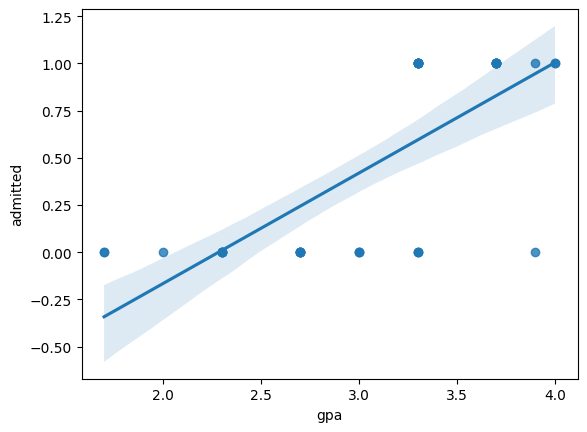

In [4]:
import seaborn as sns
sns.regplot(x='gpa',y='admitted',data=data)

If p >= 0.5, then the candidate is getting admitted. If p < 0.5, then the candidate is not getting admitted.

# Confusion Matrix

<Axes: xlabel='Predicted', ylabel='Actual'>

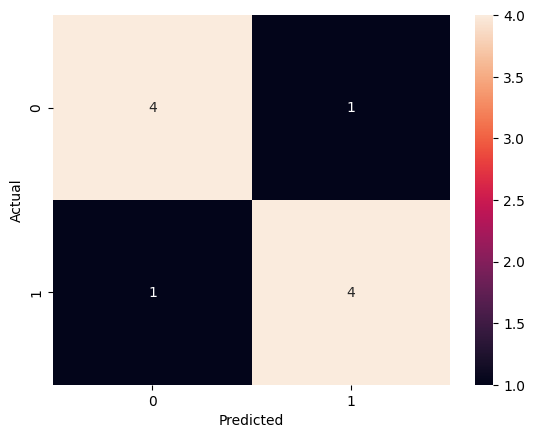

In [5]:
confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(confusion_matrix, annot=True)

# Classification Report

In [6]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10

